# StreamAlpha Research Notebook

Explores the two online anomaly detectors this project runs in production
(`streaming/models.py`) and cross-references streamalpha's real detected
anomalies against alpha-signal-lab's factor computation
(`analysis/cross_reference.py`). Real production data where it exists
(the anomalies table has a handful of rows so far -- this project is
young); synthetic data where it's used is explicitly generated in this
notebook, not disguised as real.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import random  # noqa: E402
from datetime import UTC, datetime, timedelta  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
from config.universe import UNIVERSE  # noqa: E402
from data.prices import load_prices  # noqa: E402
from dotenv import load_dotenv  # noqa: E402

from analysis.cross_reference import (  # noqa: E402
    compute_factor_move_z_scores,
    cross_reference,
    load_anomalies,
    sharp_moves_only,
)
from storage.db import get_connection, list_anomalies  # noqa: E402
from streaming.aggregation import WindowSummary  # noqa: E402
from streaming.models import RegimeChange, TickerModels, VolumeAnomaly  # noqa: E402

load_dotenv(REPO_ROOT / ".env")
pd.set_option("display.precision", 4)

## Detected anomalies (real data)

Every anomaly streamalpha has actually detected against live Alpaca
paper-account data, as currently stored in Postgres.

In [2]:
conn = get_connection()
try:
    anomalies_df = pd.DataFrame(list_anomalies(conn, limit=200))
finally:
    conn.close()

print(f"{len(anomalies_df)} anomalies detected so far")
anomalies_df  # noqa: B018

3 anomalies detected so far


,ticker,window_start,anomaly_type,details,detected_at
0,AXP,2026-08-03 18:54:30.964939+00:00,regime_change,"{'symbol': 'AXP', 'window_end': '2026-08-03T18...",2026-08-03 18:55:11.042388+00:00
1,BMY,2026-08-03 18:34:47.210479+00:00,regime_change,"{'symbol': 'BMY', 'window_end': '2026-08-03T18...",2026-08-03 18:34:57.733568+00:00
2,COP,2026-08-03 18:31:35.451315+00:00,regime_change,"{'symbol': 'COP', 'window_end': '2026-08-03T18...",2026-08-03 18:31:55.417644+00:00


## Volume-spike detector: behavior on synthetic data

`streaming/models.py`'s volume detector flags a window whose volume is
more than `DEFAULT_VOLUME_Z_THRESHOLD` (4.5) standard deviations above a
rolling mean of the last `DEFAULT_VOLUME_LOOKBACK` (30) windows. This
replaced an earlier `river` `HalfSpaceTrees`-based design that caught an
isolated spike only 1-3/10 times across random seeds; see the module
docstring for the full sweep that motivated the redesign. No real volume
anomaly has fired yet (see the table above), so this is demonstrated on
the same kind of synthetic isolated-spike scenario used to tune it.

detected at window 150: z-score=1223.0, rolling mean=972, rolling std=81


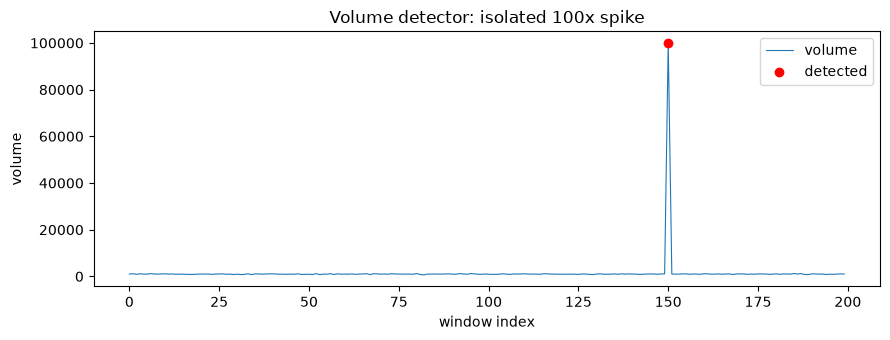

In [3]:
def make_window(i, volume, base=datetime(2024, 1, 1, tzinfo=UTC)):
    ts = base + timedelta(seconds=10 * i)
    return WindowSummary(
        symbol="DEMO",
        window_start=ts,
        window_end=ts + timedelta(seconds=10),
        trade_count=5,
        volume=volume,
        realized_volatility=0.01,
    )


random.seed(3)
N, SPIKE_AT = 200, 150
volumes = [100_000.0 if i == SPIKE_AT else random.gauss(1000, 100) for i in range(N)]

models = TickerModels("DEMO")
detected_at = None
for i, v in enumerate(volumes):
    for event in models.process_window(make_window(i, v)):
        if isinstance(event, VolumeAnomaly):
            detected_at = i
            print(f"detected at window {i}: z-score={event.anomaly_score:.1f}, "
                  f"rolling mean={event.score_mean:.0f}, rolling std={event.score_std:.0f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(volumes, linewidth=0.8, label="volume")
if detected_at is not None:
    ax.scatter([detected_at], [volumes[detected_at]], color="red", zorder=5, label="detected")
ax.set_title("Volume detector: isolated 100x spike")
ax.set_xlabel("window index")
ax.set_ylabel("volume")
ax.legend()
plt.tight_layout()
plt.show()

## Regime-change detector: BOCPD behavior on synthetic data

`streaming/changepoint.py` implements Bayesian Online Changepoint
Detection from scratch (`river` has no BOCPD implementation). This is
the detector behind all 3 real anomalies above -- demonstrated here on a
clean synthetic volatility shift so the changepoint-probability dynamics
are visible directly, not just the binary "flagged or not" outcome.

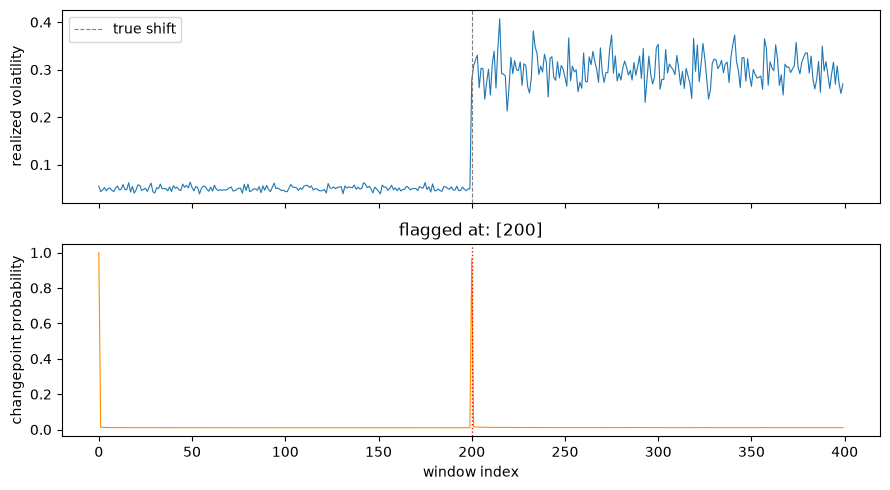

In [4]:
random.seed(0)
N, SHIFT_AT = 400, 200
volatilities = [
    abs(random.gauss(0.3, 0.03)) if i >= SHIFT_AT else abs(random.gauss(0.05, 0.005))
    for i in range(N)
]

def make_vol_window(i, volatility, base=datetime(2024, 1, 1, tzinfo=UTC)):
    ts = base + timedelta(seconds=10 * i)
    return WindowSummary(
        symbol="DEMO2",
        window_start=ts,
        window_end=ts + timedelta(seconds=10),
        trade_count=5,
        volume=1000.0,
        realized_volatility=volatility,
    )


models = TickerModels("DEMO2")
probs = []
regime_flags = []
for i, vol in enumerate(volatilities):
    for event in models.process_window(make_vol_window(i, vol)):
        if isinstance(event, RegimeChange):
            regime_flags.append(i)
    probs.append(models._bocpd.changepoint_probability)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(volatilities, linewidth=0.8)
axes[0].axvline(SHIFT_AT, color="gray", linestyle="--", linewidth=0.8, label="true shift")
axes[0].set_ylabel("realized volatility")
axes[0].legend()
axes[1].plot(probs, linewidth=0.8, color="darkorange")
for f in regime_flags:
    axes[1].axvline(f, color="red", linestyle=":", linewidth=1.0)
axes[1].set_ylabel("changepoint probability")
axes[1].set_xlabel("window index")
axes[1].set_title(f"flagged at: {regime_flags}")
plt.tight_layout()
plt.show()

## Cross-reference analysis: real anomalies vs alpha-signal-lab factors

Reruns `analysis/cross_reference.py`'s actual logic (not a
reimplementation) against the real anomalies loaded above and
alpha-signal-lab's real factor computation over real price history.

In [5]:
conn = get_connection()
try:
    anomalies_for_xref = load_anomalies(conn)
finally:
    conn.close()

if anomalies_for_xref.empty:
    print("No anomalies to cross-reference yet.")
else:
    tickers = sorted(set(UNIVERSE) | set(anomalies_for_xref["ticker"]))
    end = datetime.now(UTC).date() + timedelta(days=1)
    start = end - timedelta(days=400)
    prices = load_prices(tickers, start.isoformat(), end.isoformat())

    factor_z = compute_factor_move_z_scores(prices)
    sharp = sharp_moves_only(factor_z)
    result = cross_reference(anomalies_for_xref, sharp)

    n_matched = int(result["coincides_with_sharp_factor_move"].sum())
    print(f"{n_matched}/{len(result)} detected anomalies coincided with a sharp factor move")
    result  # noqa: B018

1/3 detected anomalies coincided with a sharp factor move
